In [ ]:
import os
os.chdir("/home/jacob/data_processing")

# import matplotlib
# matplotlib.use("pgf") 

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

fm.fontManager.addfont("/home/jacob/fonts/cmunrm.ttf")

# plt.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     "font.family": "serif",
#     "font.serif": ["CMU Serif"],
#     "font.size": 11,
#     "text.usetex": True,
#     "pgf.rcfonts": False,
# })

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fm.fontManager.addfont("/home/jacob/fonts/cmunrm.ttf")
plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["font.size"] = 11

# sns.set_theme(
#     style="white",
#     context="paper",        
#     font="serif",
#     font_scale=1.0,
# )

In [3]:
base_dir = Path("/home/jacob/data_processing/data")

datasets_water = {
    f"{p.parent.parent.name}_water_{p.parent.name}_df": p
    for p in sorted(base_dir.glob("*/*/pore_metrics.csv"))
}

water_dfs = {
    label: pd.read_csv(path).assign(dataset=label)
    for label, path in datasets_water.items()
}

print(water_dfs.keys())

water_df = pd.concat(water_dfs.values(), ignore_index=True)

# print(water_df)

for label, data in water_dfs.items():
    globals()[label] = data

double_water_df = water_df[water_df["dataset"].str.match(r"double_water_\d")]
no_metal_double_water_df = water_df[water_df["dataset"].str.match(r"no_metal_double_water")]
no_metal_rut_pep_water_df = water_df[water_df["dataset"].str.match(r"no_metal_rut_pep_water")]
rut_pep_water_df = water_df[water_df["dataset"].str.match(r"rut_pep_water")]
double_long_water_df = water_df[water_df["dataset"].str.match(r"double_long_water")]
no_metal_double_long_water_df = water_df[water_df["dataset"].str.match(r"no_metal_double_long_water")]
no_metal_rut_pep_long_water_df = water_df[water_df["dataset"].str.match(r"no_metal_rut_pep_long_water")]
no_metal_rut_pep_long_water_no_15_df = water_df[water_df["dataset"].str.match(r"no_metal_rut_pep_long_water_(5|16)", na=False)]
rut_pep_long_water_df = water_df[water_df["dataset"].str.match(r"rut_pep_long_water")]

dict_keys(['double_water_13_df', 'double_water_15_df', 'double_water_19_df', 'double_water_20_df', 'double_water_9_df', 'double_long_water_13_df', 'double_long_water_20_df', 'double_long_water_9_df', 'no_metal_double_water_11_df', 'no_metal_double_water_14_df', 'no_metal_double_water_15_df', 'no_metal_double_water_18_df', 'no_metal_double_water_19_df', 'no_metal_double_water_20_df', 'no_metal_double_water_3_df', 'no_metal_double_water_5_df', 'no_metal_double_water_7_df', 'no_metal_double_long_water_11_df', 'no_metal_double_long_water_15_df', 'no_metal_double_long_water_5_df', 'no_metal_rut_pep_water_10_df', 'no_metal_rut_pep_water_14_df', 'no_metal_rut_pep_water_15_df', 'no_metal_rut_pep_water_17_df', 'no_metal_rut_pep_water_18_df', 'no_metal_rut_pep_water_19_df', 'no_metal_rut_pep_water_20_df', 'no_metal_rut_pep_water_5_df', 'no_metal_rut_pep_water_6_df', 'no_metal_rut_pep_water_7_df', 'no_metal_rut_pep_long_water_15_df', 'no_metal_rut_pep_long_water_16_df', 'no_metal_rut_pep_long_wat

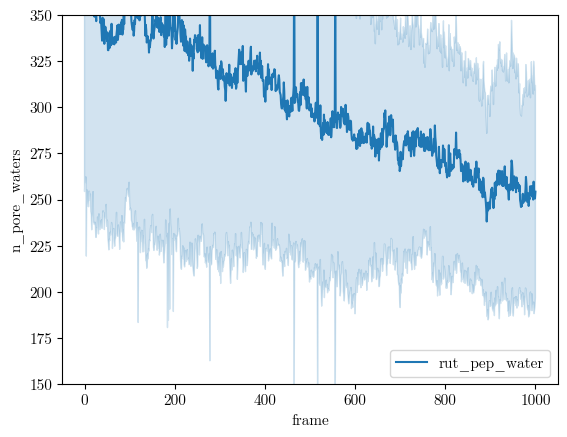

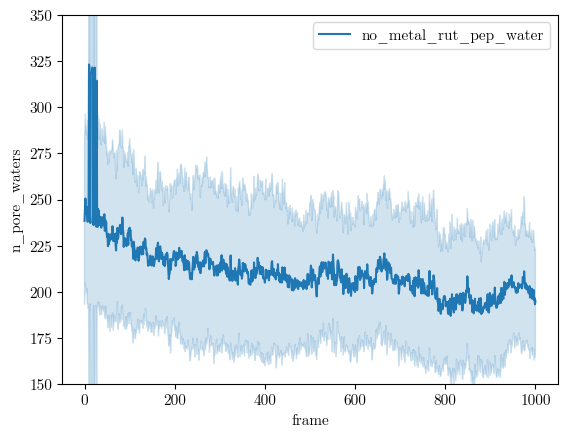

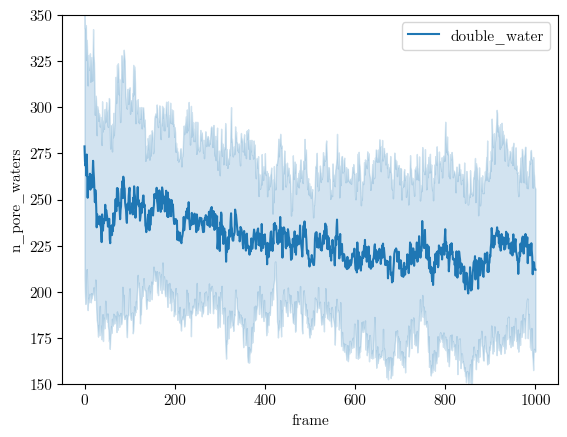

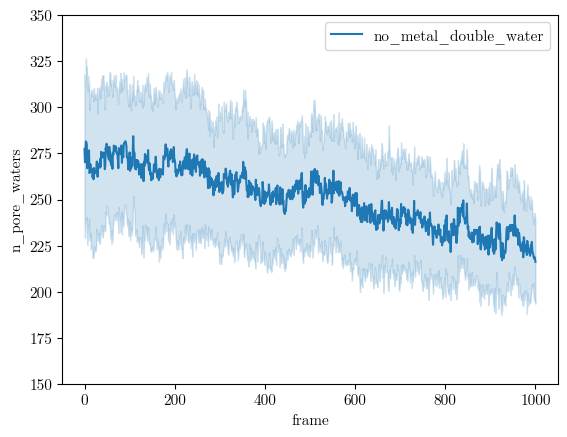

In [4]:
sns.lineplot(
    data=rut_pep_water_df, 
    x="frame", 
    y="n_pore_waters", 
    label="rut_pep_water",
    errorbar=("se", 2),
    )

plt.ylim(150, 350)
plt.show()

sns.lineplot(
    data=no_metal_rut_pep_water_df, 
    x="frame", 
    y="n_pore_waters", 
    label="no_metal_rut_pep_water",
    errorbar=("se", 2),
    )

plt.ylim(150, 350)
plt.show()

sns.lineplot(
    data=double_water_df, 
    x="frame", 
    y="n_pore_waters", 
    label="double_water",
    errorbar=("se", 2),
    )

plt.ylim(150, 350)
plt.show()

sns.lineplot(
    data=no_metal_double_water_df, 
    x="frame", 
    y="n_pore_waters", 
    label="no_metal_double_water",
    errorbar=("se", 2),
    )

plt.ylim(150, 350)
plt.show()


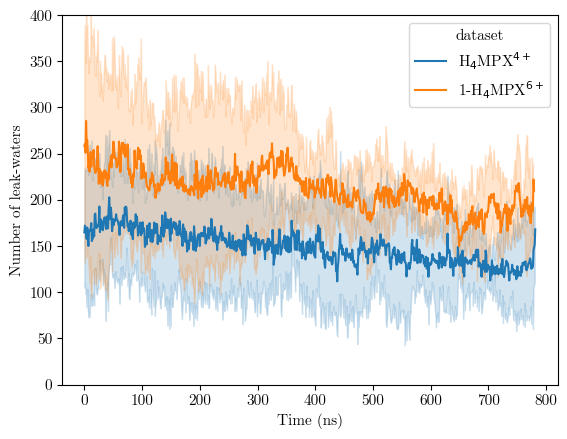

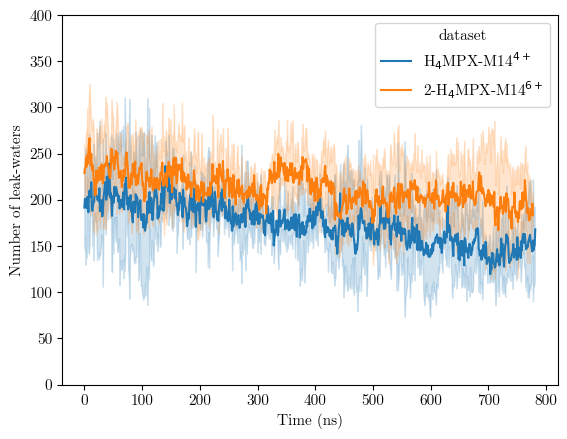

In [13]:
# print(water_df["dataset"].unique())


combined_water = pd.concat([no_metal_rut_pep_long_water_df.assign(dataset="H$_4$MPX$^{4+}$"), rut_pep_long_water_df.assign(dataset="1-H$_4$MPX$^{6+}$")])

sns.lineplot(
    data=combined_water, 
    x="frame", 
    y="n_pore_waters",
    hue="dataset",
    errorbar=("se", 2),
    )

plt.ylim(0, 400)
plt.ylabel("Number of leak-waters")
plt.xlabel("Time (ns)")
plt.savefig("/home/jacob/data_processing/data/plots/water_single.pdf", bbox_inches="tight")
plt.show()


combined_water_double = pd.concat([no_metal_rut_pep_long_water_no_15_df.assign(dataset="H$_4$MPX-M14$^{4+}$"), double_long_water_df.assign(dataset="2-H$_4$MPX-M14$^{6+}$")])

sns.lineplot(
    data=combined_water_double, 
    x="frame", 
    y="n_pore_waters",
    hue="dataset",
    errorbar=("se", 2),
    )

plt.ylim(0, 400)
plt.ylabel("Number of leak-waters")
plt.xlabel("Time (ns)")
plt.savefig("/home/jacob/data_processing/data/plots/water_double.pdf", bbox_inches="tight")
plt.show()


# plt.ylim(100, 500)
# plt.show()

# sns.lineplot(
#     data=rut_pep_long_water_df, 
#     x="frame", 
#     y="n_pore_waters", 
#     label="rut_pep_water")

# plt.ylim(150, 350)
# plt.show()

# sns.lineplot(
#     data=no_metal_double_long_water_df, 
#     x="frame", 
#     y="n_pore_waters", 
#     label="no_metal_double_long_water")

# # plt.ylim(100, 500)
# # plt.show()

# sns.lineplot(
#     data=double_long_water_df, 
#     x="frame", 
#     y="n_pore_waters", 
#     label="double_long_water")

# plt.ylim(150, 350)
# plt.show()